In [134]:
import numpy as np
from Reconstruction_coronary_arteria.Reconstruction import Reconstruction_methods
from Reconstruction_coronary_arteria.open_json import GeneratedDataset
from torchvision import transforms as T
import cv2
import torch
from matplotlib import pyplot as plt
from skimage.morphology import skeletonize

In [135]:
# Пути к данным
images_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/images/test"
labels_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/labels/test/"
info_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/info/"

# Трансформации для проекций
def mean_channel(x):
    return x.mean(axis=0)[None, :]

def distance_transform(image_mask):
    image_mask = np.asarray(image_mask)[0]
    binary_mask = (image_mask > np.mean(image_mask)).astype(np.uint8)
    distance = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)
    return torch.tensor(image_mask + distance[None, :])

images_transform = T.Compose([
    T.ToTensor(),
    T.Lambda(mean_channel),
    T.Resize((128, 128)),
    T.Lambda(distance_transform),
])

# Загрузка данных
d = GeneratedDataset(images_dir, labels_dir, info_dir, images_transform=images_transform)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

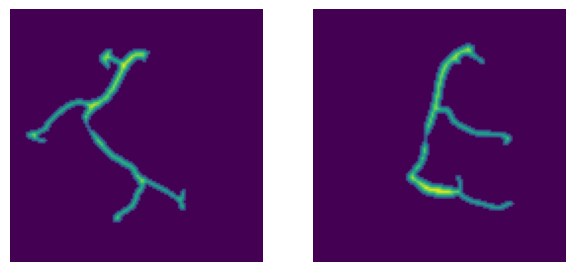

In [150]:
sample_index = 0 
sample = d[sample_index]
center_line = sample[1]
projection1 = sample[0][0]
projection2 = sample[0][1]

plt.figure(figsize=(15,15))
plt.subplot(1,4,1)
plt.imshow(projection1) #d2[1][0][0]
plt.axis('off')
plt.subplot(1,4,2)
plt.imshow(projection2)
plt.axis('off')

In [151]:
def extract_centerline(image):
    img = image.numpy() if isinstance(image, torch.Tensor) else image
    binary = (img > np.mean(img)).astype(np.uint8)
    skeleton = skeletonize(binary).astype(np.uint8)  # Скелетизация с помощью skimage
    coords = np.column_stack(np.where(skeleton > 0))  # Координаты [y, x]
    return coords

In [152]:
# Извлекаем координаты центральных линий
curve_pr1 = extract_centerline(projection1)  # Координаты для первой проекции
curve_pr2 = extract_centerline(projection2)  # Координаты для второй проекции
radius_center_line = center_line[...,3] # Radius
radius_pr1 = radius_center_line[curve_pr1[:, 0].astype(int), curve_pr1[:, 1].astype(int)]  # Радиусы для curve_pr1
radius_pr2 = radius_center_line[curve_pr2[:, 0].astype(int), curve_pr2[:, 1].astype(int)]  # Радиусы для curve_pr2
images, label, theta, phi = d[sample_index]
theta_1 = theta[0].numpy()
theta_2 = theta[1].numpy()
phi1 = phi[0].numpy()
phi2 = phi[1].numpy()
angles1 = [theta_1, phi1]
angles2 = [theta_2, phi2]


IndexError: index 20 is out of bounds for dimension 0 with size 4

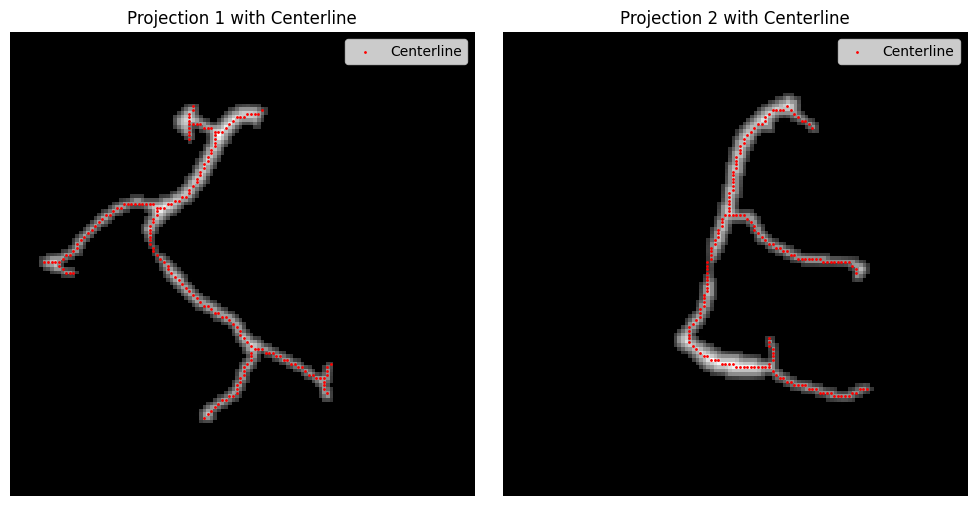

In [153]:
plt.figure(figsize=(10, 5))

# Первая проекция
plt.subplot(1, 2, 1)
plt.imshow(projection1, cmap='gray')
plt.scatter(curve_pr1[:, 1], curve_pr1[:, 0], c='red', s=1, label='Centerline')
plt.title("Projection 1 with Centerline")
plt.axis('off')
plt.legend()

# Вторая проекция
plt.subplot(1, 2, 2)
plt.imshow(projection2, cmap='gray')
plt.scatter(curve_pr2[:, 1], curve_pr2[:, 0], c='red', s=1, label='Centerline')
plt.title("Projection 2 with Centerline")
plt.axis('off')
plt.legend()

plt.tight_layout()
plt.show()

In [155]:
recon = Reconstruction_methods(curve_pr1,curve_pr2,radius_pr1,radius_pr2,angles1,angles2)
recon.calibrate() # калибровка
recon.partial_matching() # сопоставление точек 
recon.reconstruct_3d_curve() # 3д реконструкция
recon.show_epipolar_line()
recon.plot_curve_3d()


NameError: name 'radius_pr1' is not defined

ПРИМЕР!

In [33]:
curve_proj1 = np.array([[0,0],[1,1],[2,2],[3,3],[4,4],[5,5],[6,6],[7,7]])
curve_proj2 = np.array([[0,0],[1,1],[2,2],[3,3],[4,4],[5,5],[6,6],[7,7]])
rad_proj1 = np.array([1,1,1,1,1,1,1,1])
rad_proj2 = np.array([1,1,1,1,1,1,1,1])
angles1 = [0,0]
angles2 = [90,30]

recon = Reconstruction_methods(curve_proj1,curve_proj2,rad_proj1,rad_proj2, angles1, angles2)

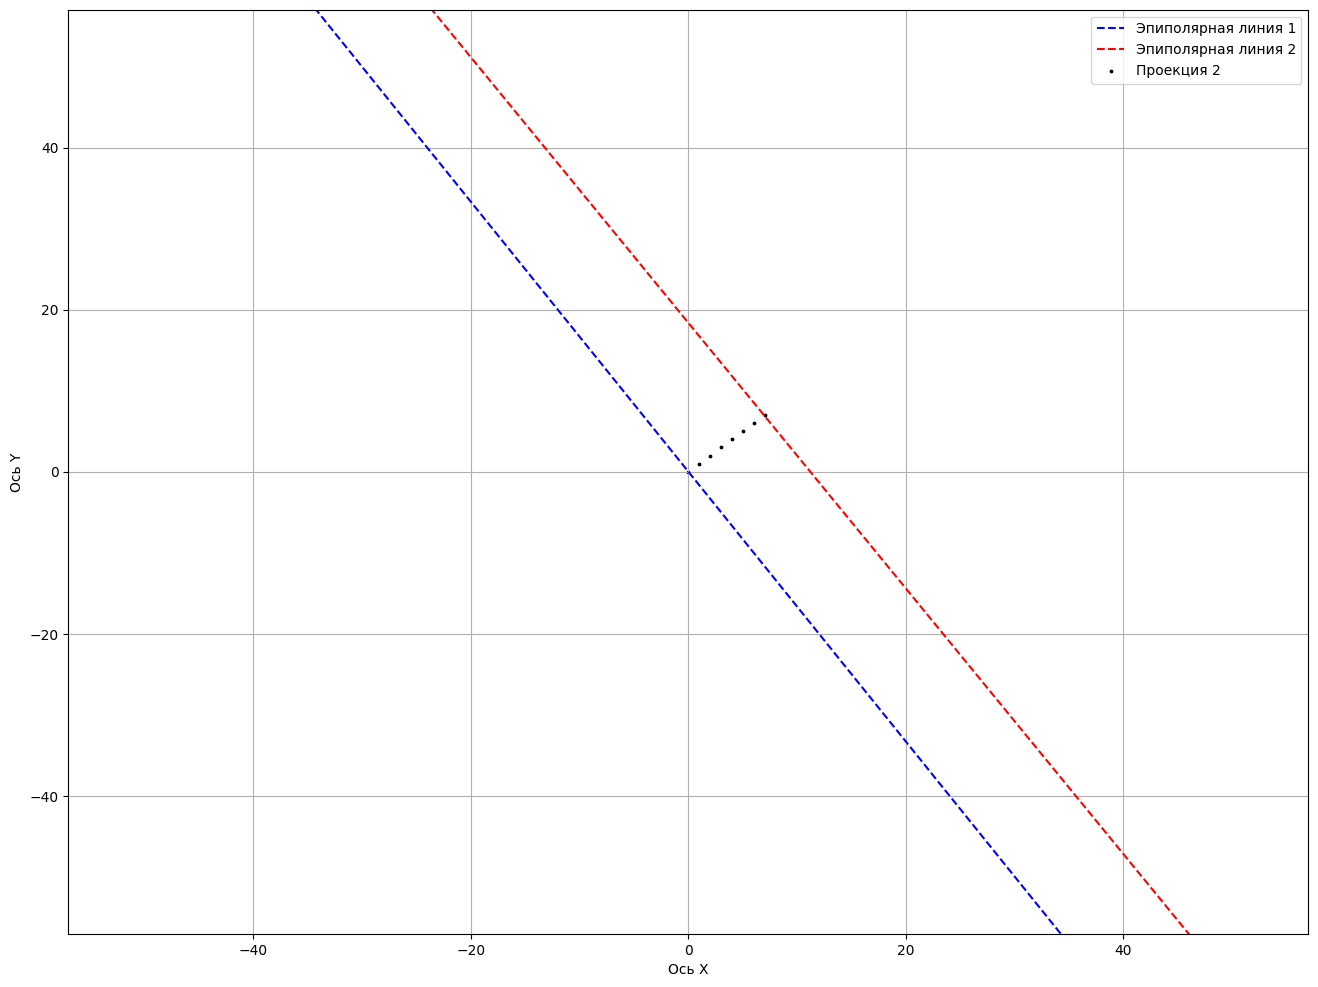

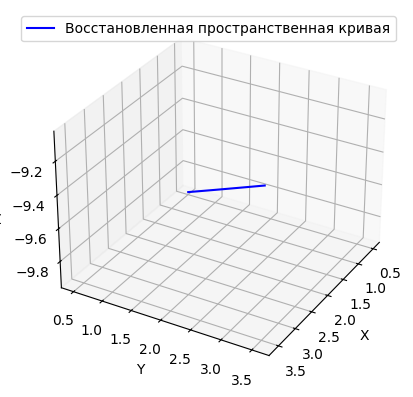

In [ ]:
recon.calibrate() # калибровка
recon.partial_matching() # сопоставление точек 
recon.reconstruct_3d_curve() # 3д реконструкция
recon.show_epipolar_line()
recon.plot_curve_3d()


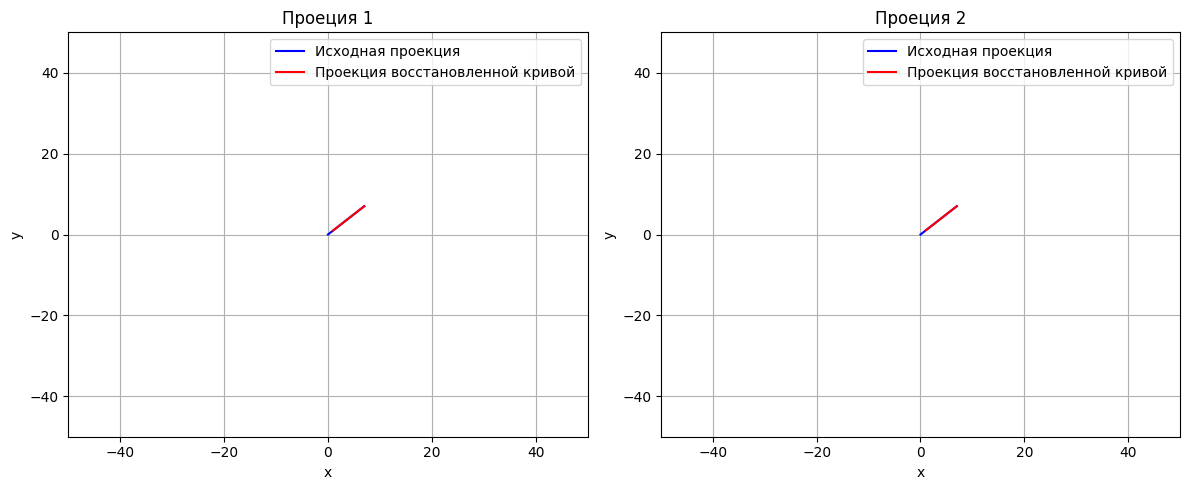

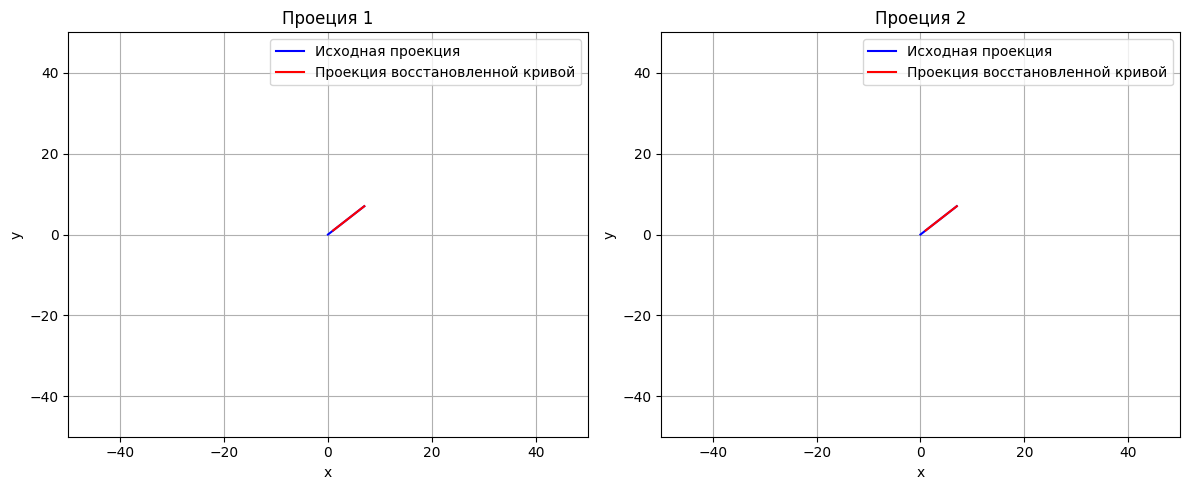

In [ ]:

recon.show_reprojection_curve_3d()
recon.show_matched()


In [ ]:

# Параметрическая спираль
t = np.linspace(0, 10, 100)  # Параметр
x = np.cos(t)  # Координата X
y = np.sin(t)  # Координата Y
z = t / 10     # Координата Z (медленный рост по Z)
curve_3d = np.vstack((x, y, z)).T  # Объединяем в массив формы (100, 3)

# Проекции под разными углами (упрощенные для примера)
# Проекция 1: плоскость XY
curve_pr1 = curve_3d[:, :2]  # Берем только X и Y

# Проекция 2: поворот на 30 градусов вокруг оси Z
angle = np.radians(30)
curve_pr2 = np.zeros_like(curve_pr1)
curve_pr2[:, 0] = curve_3d[:, 0] * np.cos(angle) - curve_3d[:, 1] * np.sin(angle)  # X' = X*cos(θ) - Y*sin(θ)
curve_pr2[:, 1] = curve_3d[:, 0] * np.sin(angle) + curve_3d[:, 1] * np.cos(angle)  # Y' = X*sin(θ) + Y*cos(θ)

# Радиусы (для простоты зададим константы)
radius_pr1 = np.ones(len(t))
radius_pr2 = np.ones(len(t))

# Углы для проекций
angles1 = [0, 0]    # Первая проекция без поворота
angles2 = [90, 30]   # Вторая проекция с поворотом на 30 градусов

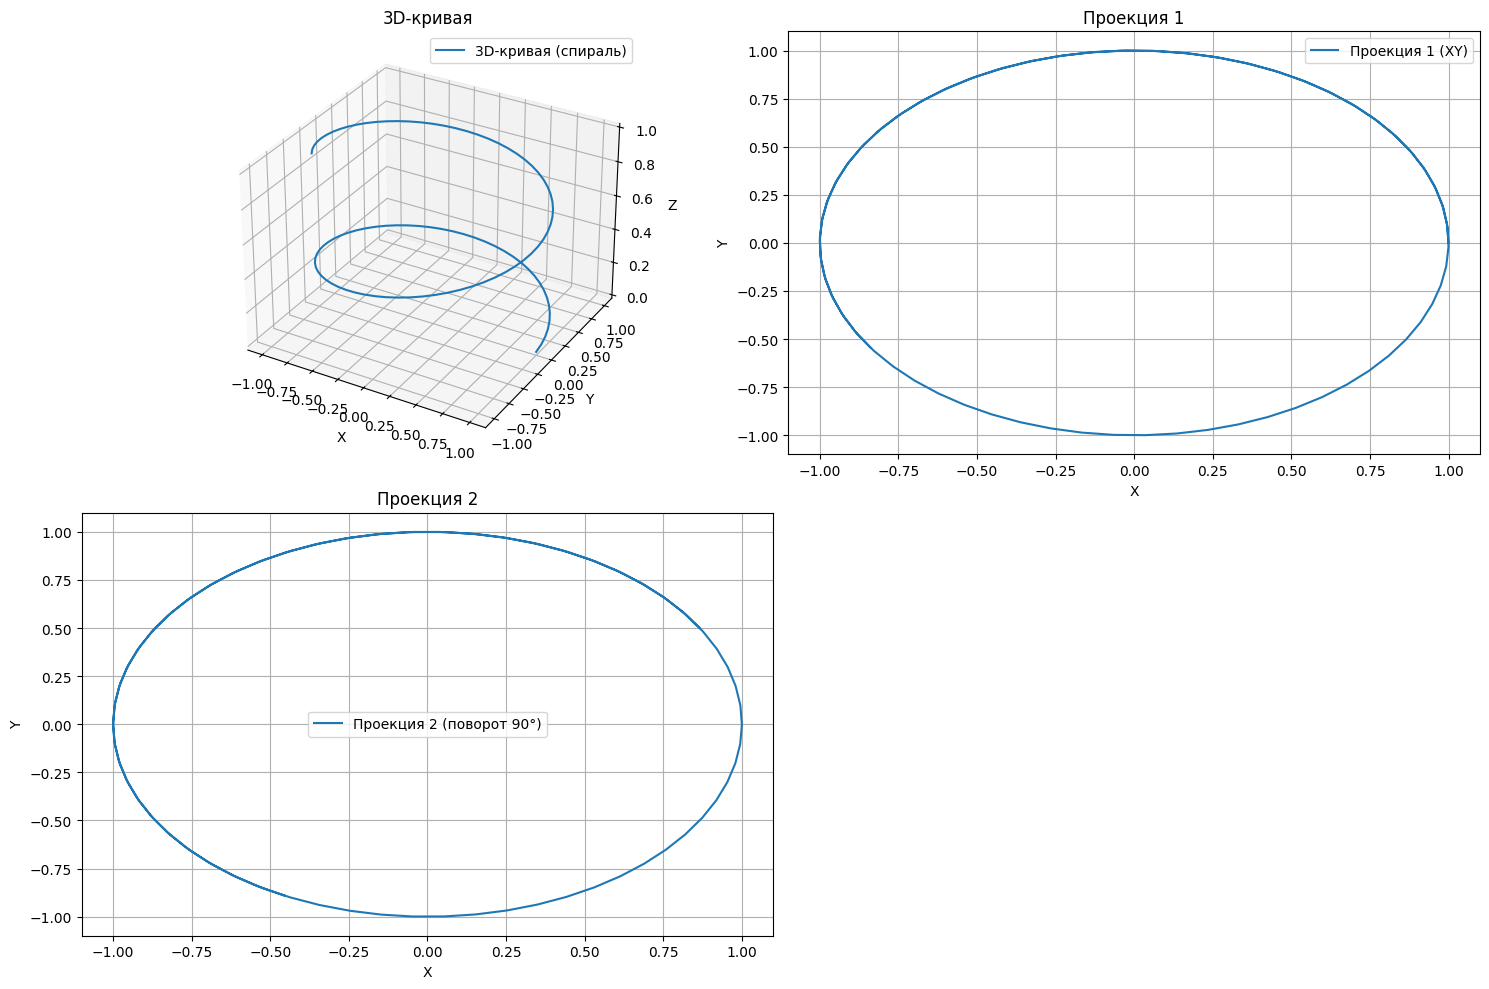

In [ ]:
# Ячейка 3: Визуализация 3D-кривой и проекций
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Создаем фигуру с несколькими подграфиками
fig = plt.figure(figsize=(15, 10))

# 3D-кривая
ax1 = fig.add_subplot(221, projection='3d')
ax1.plot(curve_3d[:, 0], curve_3d[:, 1], curve_3d[:, 2], label='3D-кривая (спираль)')
ax1.set_title('3D-кривая')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.legend()

# Проекция 1 (XY)
ax2 = fig.add_subplot(222)
ax2.plot(curve_pr1[:, 0], curve_pr1[:, 1], label='Проекция 1 (XY)')
ax2.set_title('Проекция 1')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.legend()
ax2.grid(True)

# Проекция 2 (поворот на 30 градусов)
ax3 = fig.add_subplot(223)
ax3.plot(curve_pr2[:, 0], curve_pr2[:, 1], label='Проекция 2 (поворот 90°)')
ax3.set_title('Проекция 2')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.legend()
ax3.grid(True)

# Пространство для дополнительной визуализации (опционально)
ax4 = fig.add_subplot(224)
ax4.axis('off')  # Пустой график для симметрии

plt.tight_layout()
plt.show()

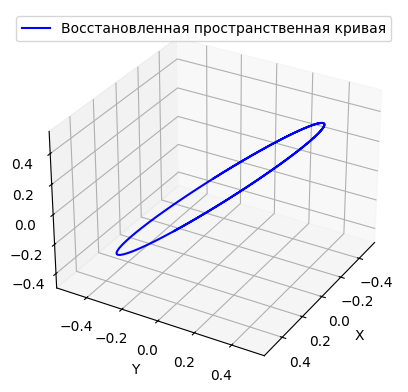

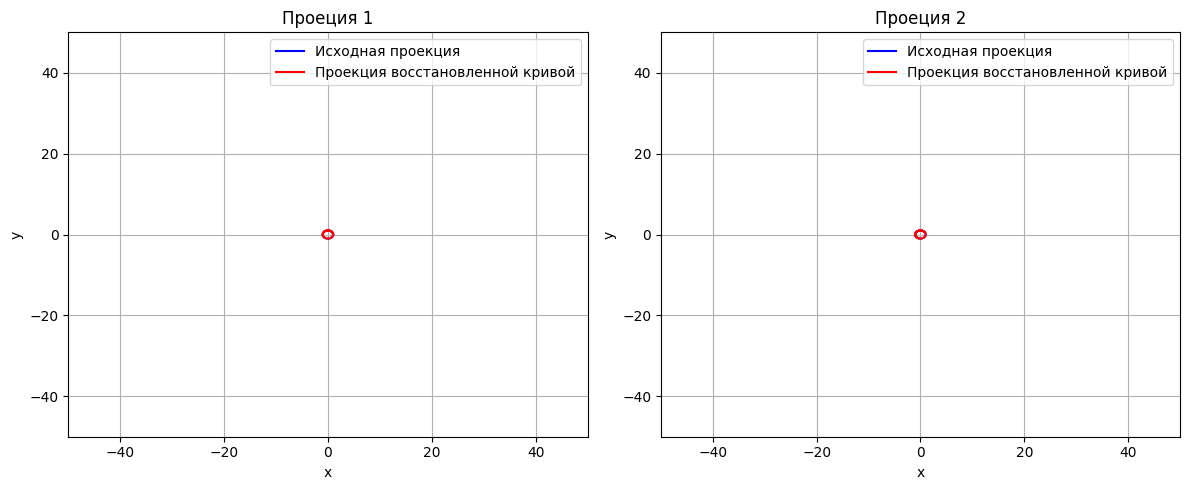

In [ ]:

# Создаем экземпляр класса с нашими данными
recon = Reconstruction_methods(curve_pr1, curve_pr2, radius_pr1, radius_pr2, angles1, angles2)

# Выполняем шаги реконструкции
recon.calibrate()           # Калибровка параметров
recon.partial_matching()    # Сопоставление точек
recon.reconstruct_3d_curve()  # Реконструкция 3D-кривой

# Визуализируем результаты
recon.plot_curve_3d()              # Восстановленная 3D-кривая
recon.show_reprojection_curve_3d() # Сравнение проекций

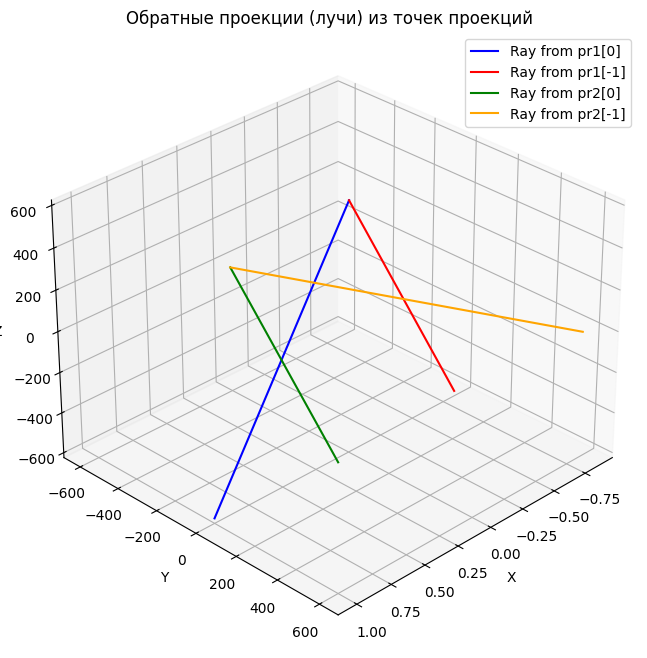

In [ ]:
# Ячейка: Визуализация обратных проекций (лучей)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Функция для вычисления точек вдоль луча
def get_ray_points(point, angles, rot_angles, trans_2d, trans_3d, lam_range):
    lam_values = np.linspace(lam_range[0], lam_range[1], 100)  # 100 точек вдоль луча
    ray_points = np.array([
        recon.ray_from_projection(lam, angles, point, rot_angles, trans_2d, trans_3d)
        for lam in lam_values
    ])
    return ray_points

# Выбираем точки для визуализации (например, первую и последнюю из каждой проекции)
points_to_show = [
    (curve_pr1[0], angles1, [0, 0, 0], [0, 0], [0, 0, 0]),  # Первая точка первой проекции
    (curve_pr1[-1], angles1, [0, 0, 0], [0, 0], [0, 0, 0]),  # Последняя точка первой проекции
    (curve_pr2[0], angles2, recon.rot_3d_angles, recon.trans_2d, recon.trans_3d),  # Первая точка второй проекции
    (curve_pr2[-1], angles2, recon.rot_3d_angles, recon.trans_2d, recon.trans_3d),  # Последняя точка второй проекции
]

# Диапазон значений lam (длина вдоль луча)
lam_range = [0, 1200]  # От 0 до максимальной длины (по умолчанию f=1200 в классе)

# Вычисляем точки для лучей
rays = [get_ray_points(point, angles, rot, t2d, t3d, lam_range) for point, angles, rot, t2d, t3d in points_to_show]

# Визуализация
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Рисуем лучи
colors = ['blue', 'red', 'green', 'orange']
labels = ['Ray from pr1[0]', 'Ray from pr1[-1]', 'Ray from pr2[0]', 'Ray from pr2[-1]']
for ray, color, label in zip(rays, colors, labels):
    ax.plot(ray[:, 0], ray[:, 1], ray[:, 2], color=color, label=label)

# Настройка графика
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Обратные проекции (лучи) из точек проекций')
ax.legend()
ax.view_init(elev=30, azim=45)  # Угол обзора

plt.show()